# Bank Maketing Compaign Perfomance Analysis


### Import required libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv("C:/Users/sahug/Downloads/archive (4)/bank.csv")
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [4]:
print("No of Rows:", df.shape[0])

No of Rows: 11162


In [5]:
print("No of columns:", df.shape[1])

No of columns: 17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Total Successful Campaign Outcomes

In [15]:
subscribed_count_data = df.loc[df['deposit'] == 'yes']
subscribed_count = subscribed_count_data['deposit'].count()
print("Total Successful Campaign Outcomes: ", subscribed_count)

Total Successful Campaign Outcomes:  5289


### Deposit Subscription(conversion) Rate (%)

In [16]:
rate = subscribed_count*100/df['deposit'].count()
print("Deposit Subscription Rate (%): ", f"{rate:.2f}%")

Deposit Subscription Rate (%):  47.38%


### Contacts per Successful Deposit

In [6]:
Total_contacts = df['campaign'].sum()
Avg = Total_contacts/subscribed_count
print("Contacts per Successful Deposit: ", round(Avg))

Contacts per Successful Deposit:  5


### Conversion rate by number of contacts in the campaign

In [45]:
def fun(x):
    if x ==1:
        return '1'
    elif x>1 and x <= 5:
        return "2-5"
    elif x>5 and x<=8:
        return "5+"
    else:
        return "8+"
df['calls'] = df['campaign'].apply(fun)

conversion_rate = ( df.groupby('calls')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print(conversion_rate)

  calls  conversion_rate(%)
0     1               53.38
1   2-5               45.02
2    5+               32.14
3    8+               24.55


### Conversion Rate by number of calls

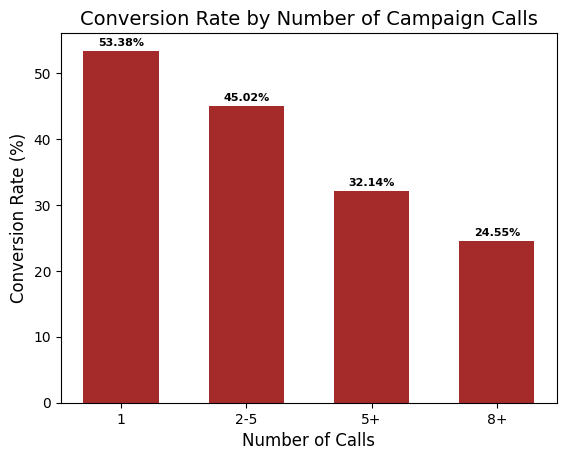

In [46]:
plt.bar(conversion_rate['calls'], conversion_rate['conversion_rate(%)'], color='brown', width = 0.6)

plt.xlabel('Number of Calls', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.title('Conversion Rate by Number of Campaign Calls', fontsize=14)

# Adding data labels on top of bars
for i, val in enumerate(conversion_rate['conversion_rate(%)']):
    plt.text(i, val + 0.75, f'{val:.2f}%', ha='center', fontweight='bold', fontsize = 8)

plt.show()

### Subscription rate by contact type

In [25]:
subscription_rate = (df.groupby('contact')['deposit']
                    .apply(lambda x: round((x == 'yes').mean()*100,2))
                    .reset_index(name = 'subscription rate(%)'))

print(subscription_rate)

     contact  subscription rate(%)
0   cellular                 54.33
1  telephone                 50.39
2    unknown                 22.59


### Conversion rate by month and contact

In [27]:
conversion_rate = df.pivot_table(
    index = ['month'],
    columns = ['contact'],
    values = 'deposit',
    aggfunc = lambda x: round((x == 'yes').mean()*100,2)
)
print("conversion rate by month and contact(in percentage %):")
print()
print(conversion_rate)

conversion rate by month and contact(in percentage %):

contact  cellular  telephone  unknown
month                                
jan         42.30      31.58   100.00
feb         57.58      48.72    80.00
mar         89.88      88.00   100.00
apr         62.19      63.93   100.00
may         48.32      31.00    18.46
jun         83.55      74.07    25.37
jul         43.16      32.80    26.19
aug         44.87      58.18    38.46
sep         87.00      80.65    27.27
oct         81.64      86.36    80.95
nov         41.89      44.32    76.47
dec         95.56      73.68     0.00


C:\Users\sahug\AppData\Local\Temp\ipykernel_324\2130205368.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  conversion_rate = df.pivot_table(


### conversion rate Heatmap (month and contact)

Text(0.5, 1.0, 'Conversion Rate Heatmap')

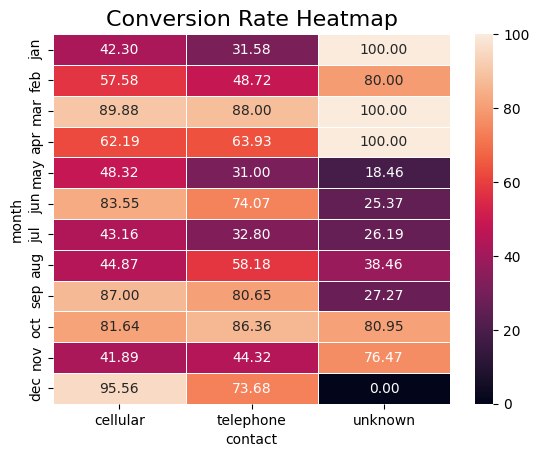

In [28]:
sns.heatmap(conversion_rate, linewidths=0.5, annot = True, fmt='.2f')
plt.title("Conversion Rate by month and contact type (Heatmap)", fontsize=16)

### Average Call Duration per Successful Deposit

In [8]:
subscribed_count_data = df.loc[df['deposit'] == 'yes']
subscribed_count = subscribed_count_data['deposit'].count()

total_call_duration = subscribed_count_data['duration'].sum()

print("Average Call Duration per Successful Deposit(in seconds): ", round(total_call_duration/subscribed_count))

Average Call Duration per Successful Deposit(in seconds):  537


### Call Duration Distribution (Boxplot)

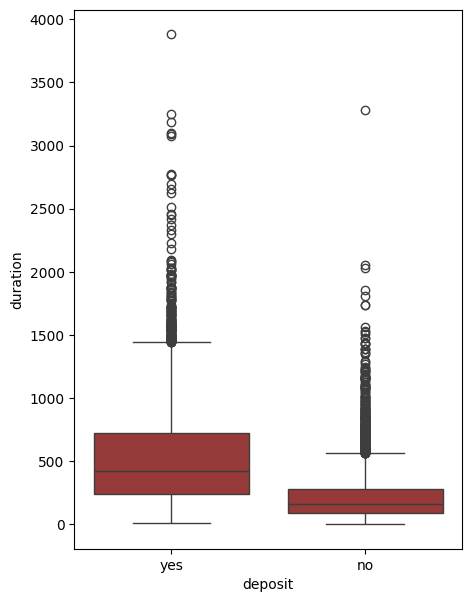

In [44]:
plt.figure(figsize = (5,7))
sns.boxplot(x="deposit", y="duration", data=df, color = 'brown')
plt.show()

### Deposit subscription rates by Housing and Personal Loan

In [41]:
# For Housing Loan
housing_conversion = (
    df.groupby('housing')['deposit']
      .apply(lambda x: round((x == 'yes').mean() * 100,2))
      .reset_index(name='Housing_loan(%)')
)

print(housing_conversion)
print()

#For Personal Loan
loan_conversion = (
    df.groupby('loan')['deposit']
      .apply(lambda x: round((x == 'yes').mean() * 100,2))
      .reset_index(name='personal_loan(%)')
)

print(loan_conversion)


  housing  Housing_loan(%)
0      no            57.03
1     yes            36.64

  loan  personal_loan(%)
0   no             49.53
1  yes             33.15


### Conversion rate by Housing and personal Loan

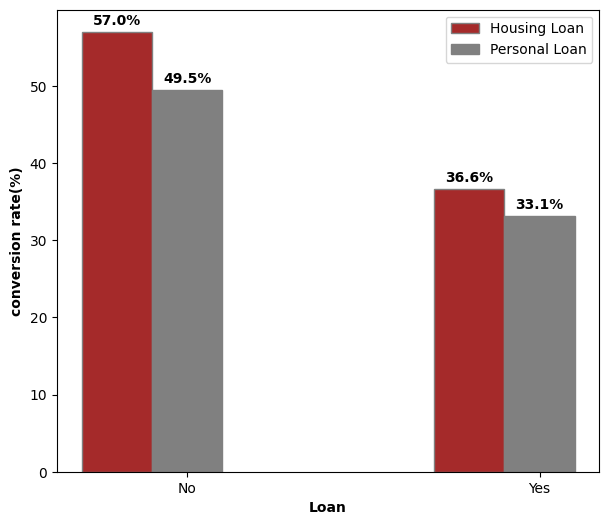

In [43]:
barWidth = 0.20
fig, ax = plt.subplots(figsize =(7, 6))  

br1 = np.arange(len(housing_conversion['Housing_loan(%)'])) 
br2 = [x + barWidth for x in br1]  

p1 = plt.bar(br1, housing_conversion['Housing_loan(%)'], color ='brown', width = barWidth, 
        edgecolor ='grey', label ='No') 
p2 = plt.bar(br2, loan_conversion['personal_loan(%)'], color ='grey', width = barWidth, 
        edgecolor ='grey', label ='Yes')  

plt.xlabel('Loan', fontweight ='bold', fontsize = 10) 
plt.ylabel('conversion rate(%)', fontweight ='bold', fontsize = 10) 
plt.xticks([r + barWidth for r in range(len(housing_conversion['Housing_loan(%)']))], 
        ['No', 'Yes'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')

plt.legend((p1[0], p2[0]), ('Housing Loan', 'Personal Loan'))
plt.show()

### Conversion Rate for Previously Successful Customers

In [39]:
conversion_rate = (
    df.groupby('poutcome')['deposit']
      .apply(lambda x: round((x == 'yes').mean() * 100,2))
      .reset_index(name='conversion_rate(%)')
)
conversion_rate['non_conversion_rate(%)'] = conversion_rate['conversion_rate(%)'].apply(lambda x: 100-x)
print(conversion_rate)

  poutcome  conversion_rate(%)  non_conversion_rate(%)
0  failure               50.33                   49.67
1    other               57.17                   42.83
2  success               91.32                    8.68
3  unknown               40.67                   59.33


### Comparision Between conversion rate and non conversion rate

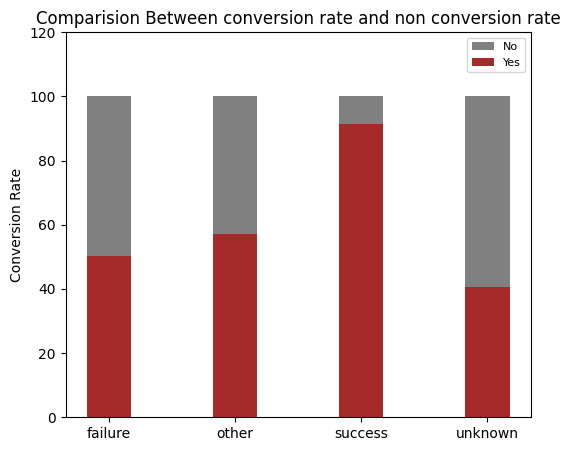

In [40]:
ind = np.arange(len(conversion_rate['poutcome']))   
width = 0.35  

fig = plt.subplots(figsize =(6, 5))
p1 = plt.bar(ind, conversion_rate['conversion_rate(%)'], width, color ='brown')
p2 = plt.bar(ind, conversion_rate['non_conversion_rate(%)'], width, color = 'grey',
             bottom = conversion_rate['conversion_rate(%)'])

plt.ylabel('Conversion Rate')
plt.title('Comparision Between conversion rate and non conversion rate')
plt.xticks(ind, ('failure', 'other', 'success', 'unknown'))
plt.yticks(np.arange(0, 121, 20))
plt.legend((p2[0], p1[0]), ('No', 'Yes'), fontsize = 8)

plt.show()

### Subscription rate by months

In [7]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

df['month'] = pd.Categorical(
    df['month'],
    categories=month_order,
    ordered=True
)

subscription_rate = (
                       df.groupby('month')['deposit']
                       .apply(lambda x: round((x == 'yes').mean()*100,2))
                       .reset_index(name = 'subscription_rate(%)')
)
print(subscription_rate)

   month  subscription_rate(%)
0    jan                 41.28
1    feb                 56.83
2    mar                 89.86
3    apr                 62.51
4    may                 32.75
5    jun                 44.68
6    jul                 41.41
7    aug                 45.29
8    sep                 84.33
9    oct                 82.40
10   nov                 42.74
11   dec                 90.91


C:\Users\sahug\AppData\Local\Temp\ipykernel_324\3658855365.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('month')['deposit']


### Subscription rate by month

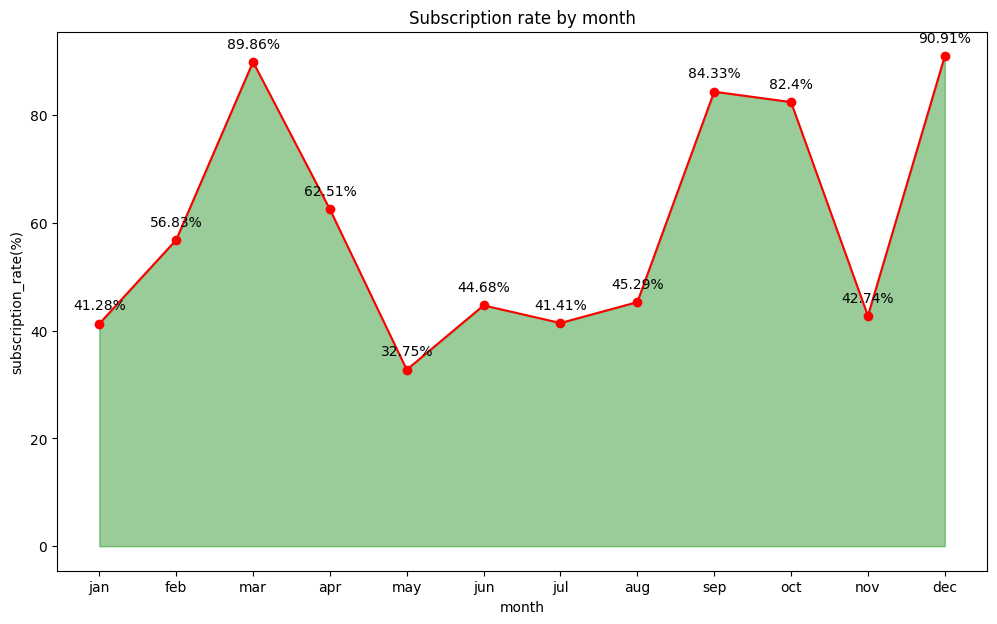

In [15]:
plt.figure(figsize=(12, 7))
plt.plot(subscription_rate['month'], subscription_rate['subscription_rate(%)'], marker='o', linestyle='-', color = 'r')
plt.fill_between(subscription_rate['month'], subscription_rate['subscription_rate(%)'], color='green', alpha=0.4)
for xi, yi in zip(subscription_rate['month'], subscription_rate['subscription_rate(%)']):
    plt.annotate(f'{yi}%',
                 (xi, yi),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center')

plt.title('Subscription rate by month')
plt.xlabel('month')
plt.ylabel('subscription_rate(%)')
plt.show()

### Conversion rate by balance lavel

In [37]:
q1 = df['balance'].quantile(0.25)
q2 = df['balance'].quantile(0.75)

def fun(x):
    if x <= q1:
        return 'Low balance'
    elif x>q1 and x <= q2:
        return "Medium balance"
    else:
        return "High balance"
df['balance_status'] = df['balance'].apply(fun)

conversion_rate = ( df.groupby('balance_status')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print(conversion_rate.sort_values(by = 'conversion_rate(%)', ascending = False))

   balance_status  conversion_rate(%)
0    High balance               57.49
2  Medium balance               48.05
1     Low balance               35.96


### Conversion rate by balance lavel

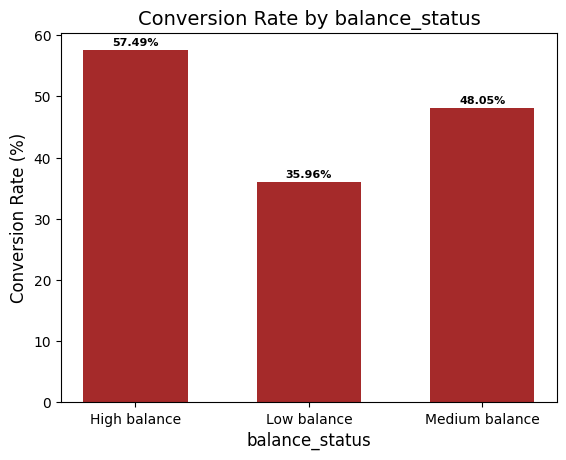

In [38]:
plt.bar(conversion_rate['balance_status'], conversion_rate['conversion_rate(%)'], color='brown', width = 0.6)

plt.xlabel('balance_status', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.title('Conversion Rate by balance_status', fontsize=14)

# Adding data labels on top of bars
for i, val in enumerate(conversion_rate['conversion_rate(%)']):
    plt.text(i, val + 0.75, f'{val:.2f}%', ha='center', fontweight='bold', fontsize = 8)

plt.show()

### Conversion rate by customer's personal information 

In [13]:
#For age 
def fun(x):
    if x >= 18 and x < 31:
        return '18-30'
    elif x>=31 and x <= 50:
        return "31-50"
    else:
        return "50+"
df['age_group'] = df['age'].apply(fun)

age_conversion_rate = ( df.groupby('age_group')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print("conversion rate by age :")
print(age_conversion_rate)
print()

# For job
job_conversion_rate = ( df.groupby('job')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print("conversion rate by job :")
print(job_conversion_rate)
print()

#For marital status
mar_conversion_rate = ( df.groupby('marital')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print("conversion rate by marital status :")
print(mar_conversion_rate)
print()

# for Education
edu_conversion_rate = ( df.groupby('education')['deposit']
                  .apply(lambda x: round((x == 'yes').mean()*100,2))
                  .reset_index(name = 'conversion_rate(%)') )
print("conversion rate by education :")
print(edu_conversion_rate)

conversion rate by age :
  age_group  conversion_rate(%)
0     18-30               57.05
1     31-50               42.35
2       50+               53.14

conversion rate by job :
              job  conversion_rate(%)
0          admin.               47.30
1     blue-collar               36.42
2    entrepreneur               37.50
3       housemaid               39.78
4      management               50.70
5         retired               66.32
6   self-employed               46.17
7        services               39.98
8         student               74.72
9      technician               46.08
10     unemployed               56.58
11        unknown               48.57

conversion rate by marital status :
    marital  conversion_rate(%)
0  divorced               48.11
1   married               43.38
2    single               54.35

conversion rate by education :
   education  conversion_rate(%)
0    primary               39.40
1  secondary               44.74
2   tertiary               54.1

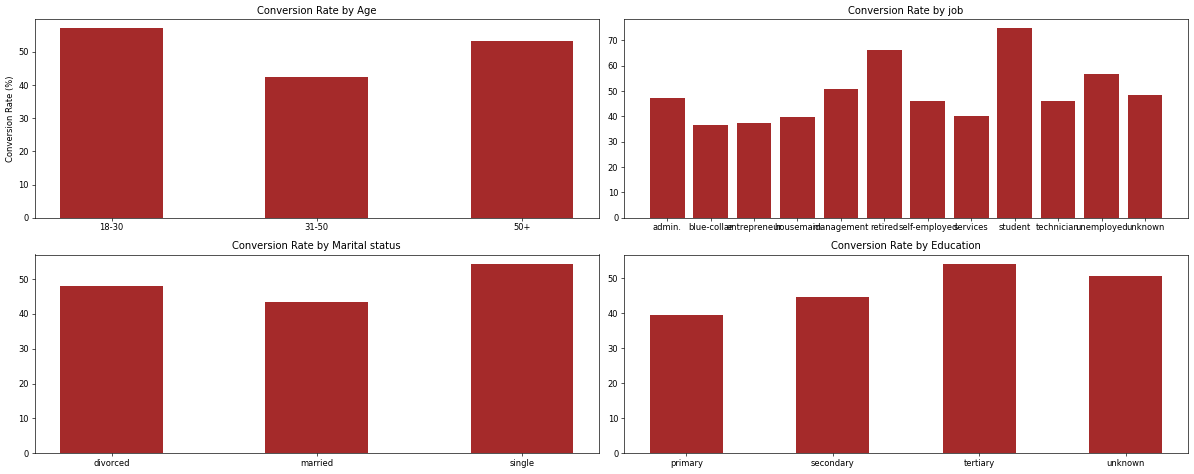

In [36]:
fig, axes = plt.subplots(2, 2,figsize = (20,8), dpi = 60)

# 1. Age
axes[0, 0].bar(age_conversion_rate['age_group'], age_conversion_rate['conversion_rate(%)'], width = 0.5, color = 'brown' )
axes[0, 0].set_title('Conversion Rate by Age')
axes[0, 0].set_ylabel('Conversion Rate (%)')

# 2. job
axes[0, 1].bar(job_conversion_rate['job'], job_conversion_rate['conversion_rate(%)'], color = 'brown')
axes[0, 1].set_title('Conversion Rate by job')

# 3. Marital_status
axes[1, 0].bar(mar_conversion_rate['marital'], mar_conversion_rate['conversion_rate(%)'], width = 0.5, color = 'brown')
axes[1, 0].set_title('Conversion Rate by Marital status')

# 4. Education
axes[1, 1].bar(edu_conversion_rate['education'], edu_conversion_rate['conversion_rate(%)'], width = 0.5, color = 'brown')
axes[1, 1].set_title('Conversion Rate by Education')

plt.tight_layout()
plt.show()
